# Tesis — Macroeconomic Variables Analysis

This notebook analyzes three macroeconomic variables:
- **CPI** (Consumer Price Index, transformed to Inflation)
- **Personal Saving Rate (PSAVERT)**
- **Yield Curve Spread (T10Y3M)**

Data source: [FRED — Federal Reserve Bank of St. Louis](https://fred.stlouisfed.org/)

**Sample period:** January 1982 – February 2026

## 0. Setup — Install & Load Packages

In [1]:
# Install if needed — run once
# !pip install pandas numpy matplotlib seaborn statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("All packages loaded successfully.")

All packages loaded successfully.


## 1. Data — Load & Prepare

### 1.1 Load CSV Files

In [2]:
# Update this path if your folder is in a different location
data_path = r"C:/Users/cufa9/Documents/Master/UdeSA/Tesis/input/"

cpi = pd.read_csv(data_path + "CPIAUCSL.csv")
psr = pd.read_csv(data_path + "PSAVERT.csv")
yc  = pd.read_csv(data_path + "T10Y3M.csv")

print(f"Rows loaded — CPI: {len(cpi)} | PSR: {len(psr)} | YC: {len(yc)}")

Rows loaded — CPI: 949 | PSR: 804 | YC: 11525


### 1.2 Parse Dates & Clean Data

In [3]:
# Parse dates
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])
psr["observation_date"] = pd.to_datetime(psr["observation_date"])
yc["observation_date"]  = pd.to_datetime(yc["observation_date"])

print(f"NA count in T10Y3M: {yc['T10Y3M'].isna().sum()}")
print(f"NA count in PSR: {psr['PSAVERT'].isna().sum()}")
print(f"NA count in T10Y3M: {cpi['CPIAUCSL'].isna().sum()}")

# Coerce yield curve to numeric (blanks become NaN)
yc["T10Y3M"] = pd.to_numeric(yc["T10Y3M"], errors="coerce")
psr["PSAVERT"] = pd.to_numeric(psr["PSAVERT"], errors="coerce")
cpi["CPIAUCSL"] = pd.to_numeric(cpi["CPIAUCSL"], errors="coerce")

NA count in T10Y3M: 480
NA count in PSR: 0
NA count in T10Y3M: 1


### 1.3 Aggregate Yield Curve from Daily to Monthly

In [4]:
# Snap all dates to the 1st of the month, then average
yc["observation_date"] = yc["observation_date"].dt.to_period("M").dt.to_timestamp()
yc_monthly = yc.groupby("observation_date", as_index=False)["T10Y3M"].mean()

print(f"Monthly YC observations: {len(yc_monthly)}")
yc_monthly.head()

Monthly YC observations: 531


,observation_date,T10Y3M
0,1982-01-01,1.676000
1,1982-02-01,0.146111
2,1982-03-01,0.546522
3,1982-04-01,0.527143
4,1982-05-01,0.908500


### 1.4 Filter to Sample Period & Merge

In [5]:
start_date = pd.Timestamp("1982-01-01")
end_date   = pd.Timestamp("2026-02-01")

cpi_trimmed = cpi.query("observation_date >= @start_date and observation_date <= @end_date")
psr_trimmed = psr.query("observation_date >= @start_date and observation_date <= @end_date")
yc_trimmed  = yc_monthly.query("observation_date >= @start_date and observation_date <= @end_date")

# Inner join on observation_date
df_final = cpi_trimmed \
    .merge(psr_trimmed, on="observation_date") \
    .merge(yc_trimmed,  on="observation_date")

print(f"Final dataset dimensions: {df_final.shape}")
df_final.head()

Final dataset dimensions: (528, 4)


,observation_date,CPIAUCSL,PSAVERT,T10Y3M
0,1982-01-01,94.4,12.6,1.676000
1,1982-02-01,94.7,12.0,0.146111
2,1982-03-01,94.7,12.1,0.546522
3,1982-04-01,95.0,12.8,0.527143
4,1982-05-01,95.9,12.2,0.908500


### 1.5 Plot Raw Data

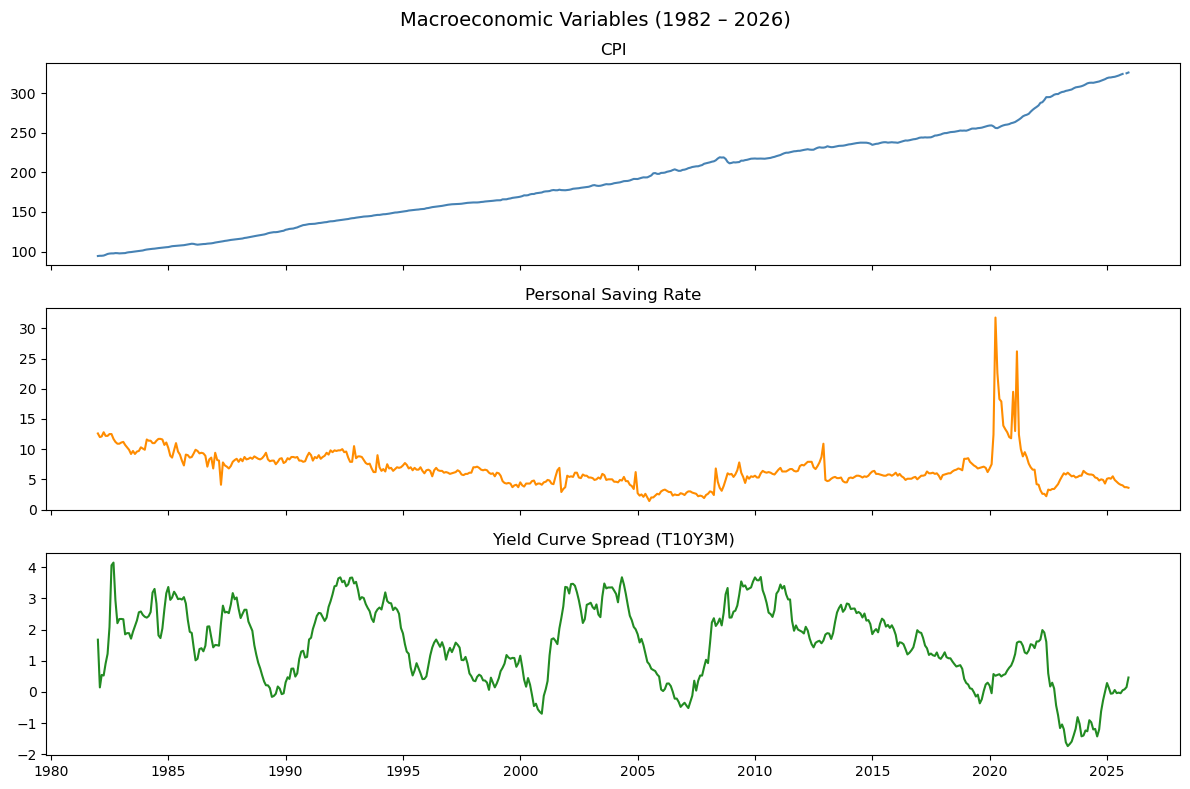

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_final["observation_date"], df_final["CPIAUCSL"], color="steelblue")
axes[0].set_title("CPI")

axes[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
axes[1].set_title("Personal Saving Rate")

axes[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
axes[2].set_title("Yield Curve Spread (T10Y3M)")

fig.suptitle("Macroeconomic Variables (1982 – 2026)", fontsize=14)
plt.tight_layout()
plt.show()

### 1.6 Diagnostic: Does saving rate visually move around yield curve inversions?

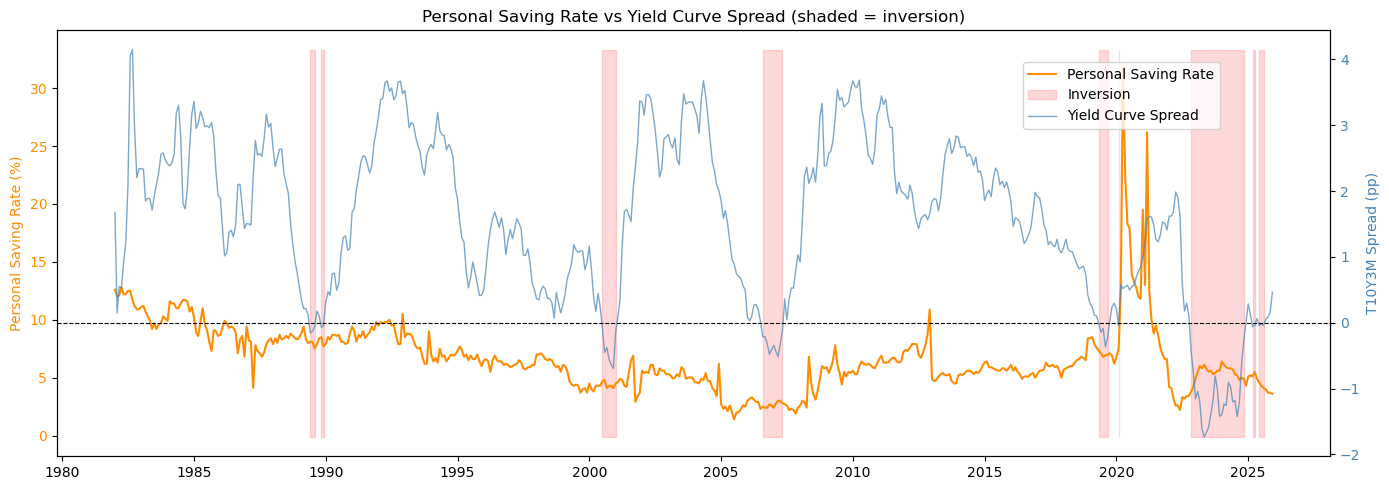

Number of inversion episodes: 9
Total months in inversion: 58 out of 528
    observation_date    T10Y3M
89        1989-06-01 -0.157273
94        1989-11-01 -0.069524
222       2000-07-01 -0.088500
295       2006-08-01 -0.213913
448       2019-05-01 -0.008182
457       2020-02-01 -0.040526
490       2022-11-01 -0.432000
518       2025-03-01 -0.055238
521       2025-06-01 -0.037500


In [7]:
##############################################################################
# Diagnostic: Does saving rate visually move around yield curve inversions?
##############################################################################

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot saving rate on left axis
ax1.plot(df_final["observation_date"], df_final["PSAVERT"], 
         color="darkorange", linewidth=1.5, label="Personal Saving Rate")
ax1.set_ylabel("Personal Saving Rate (%)", color="darkorange")
ax1.tick_params(axis="y", labelcolor="darkorange")

# Plot yield curve on right axis
ax2 = ax1.twinx()
ax2.plot(df_final["observation_date"], df_final["T10Y3M"], 
         color="steelblue", linewidth=1, alpha=0.7, label="Yield Curve Spread")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("T10Y3M Spread (pp)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# Shade inversion periods in red
inversions = df_final["T10Y3M"] < 0
ax1.fill_between(df_final["observation_date"], 
                 ax1.get_ylim()[0], ax1.get_ylim()[1],
                 where=inversions, color="red", alpha=0.15, label="Inversion")

plt.title("Personal Saving Rate vs Yield Curve Spread (shaded = inversion)")
fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

# Print inversion episodes
df_final["inversion"] = (df_final["T10Y3M"] < 0).astype(int)
df_final["inversion_start"] = (df_final["inversion"] == 1) & (df_final["inversion"].shift(1) == 0)
episodes = df_final[df_final["inversion_start"]][["observation_date", "T10Y3M"]]
print(f"Number of inversion episodes: {len(episodes)}")
print(f"Total months in inversion: {inversions.sum()} out of {len(df_final)}")
print(episodes.to_string())

---
## 2. Stationarity & Autocorrelation Checks

### 2.1 Transform CPI → Annualised Monthly Inflation Rate

The raw CPI is a **price level index** (baseline 1982–1984 = 100), not an inflation rate.
To convert it into a usable inflation series we apply three steps:

**Step 1 — Log difference** instead of a regular difference, because we care about *proportional* changes in prices, not absolute ones. A 10-point increase from 100 to 110 (10% inflation) is very different from a 10-point increase from 300 to 310 (3.3% inflation). The log difference handles this correctly:

$$\ln(CPI_t) - \ln(CPI_{t-1}) = \ln\left(\frac{CPI_t}{CPI_{t-1}}\right) \approx \text{monthly growth rate (decimal)}$$

**Step 2 — Multiply by 100** to convert the decimal into a percentage point (e.g. `0.003` → `0.3%`).

**Step 3 — Multiply by 12** to annualise the monthly rate, making it directly comparable to how inflation is reported in policy discussions and the news (e.g. the Fed's 2% annual target).

Steps 2 and 3 are combined into a single ×1200 factor:

$$\text{Inflation}_t = \left[\ln(CPI_t) - \ln(CPI_{t-1})\right] \times 1200$$

The resulting series can be interpreted as: *"if CPI kept growing at this month's rate for a full year, what would the annual inflation rate be?"*

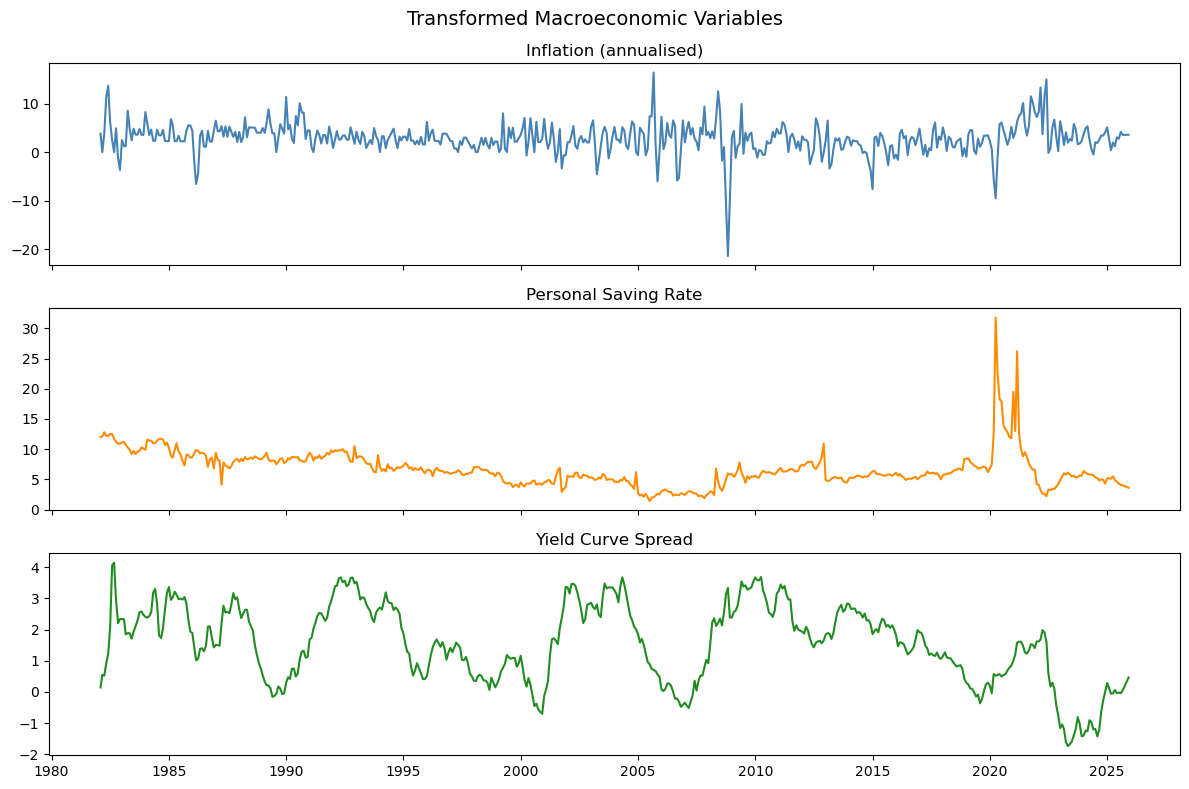

In [8]:
df_final = df_final.sort_values("observation_date").copy()
df_final["Inflation"] = (np.log(df_final["CPIAUCSL"]) - np.log(df_final["CPIAUCSL"].shift(1))) * 1200
df_final = df_final.dropna().reset_index(drop=True)

# Plot transformed series
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_final["observation_date"], df_final["Inflation"], color="steelblue")
axes[0].set_title("Inflation (annualised)")

axes[1].plot(df_final["observation_date"], df_final["PSAVERT"], color="darkorange")
axes[1].set_title("Personal Saving Rate")

axes[2].plot(df_final["observation_date"], df_final["T10Y3M"], color="forestgreen")
axes[2].set_title("Yield Curve Spread")

fig.suptitle("Transformed Macroeconomic Variables", fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 Augmented Dickey-Fuller (ADF) Tests

**H₀:** Series has a unit root (non-stationary).  
Reject H₀ if the p-value < 0.05.

In [9]:
def run_adf(series, name, regression="c"):
    """
    regression: 'c'  = constant (equivalent to R's type='drift')
                'n'  = no constant (equivalent to R's type='none')
                'ct' = constant + trend
    """
    result = adfuller(series.dropna(), autolag="AIC", regression=regression)
    print(f"=== ADF Test: {name} ===")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Lags used      : {result[2]}")
    print(f"  Critical values: ", {k: f"{v:.3f}" for k, v in result[4].items()})
    conclusion = "Reject H₀ — stationary" if result[1] < 0.05 else "Fail to reject H₀ — non-stationary"
    print(f"  Conclusion     : {conclusion}\n")

# A. Inflation — 'c' (drift): allows for non-zero mean
run_adf(df_final["Inflation"], "Inflation", regression="c")

# B. Personal Saving Rate
run_adf(df_final["PSAVERT"], "Personal Saving Rate", regression="c")

# C. Yield Curve Spread — 'n' (none): spreads often revolve around zero
run_adf(df_final["T10Y3M"], "Yield Curve Spread", regression="n")

=== ADF Test: Inflation ===
  Test Statistic : -4.1145
  p-value        : 0.0009
  Lags used      : 14
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Personal Saving Rate ===
  Test Statistic : -3.4604
  p-value        : 0.0091
  Lags used      : 13
  Critical values:  {'1%': '-3.443', '5%': '-2.867', '10%': '-2.570'}
  Conclusion     : Reject H₀ — stationary

=== ADF Test: Yield Curve Spread ===
  Test Statistic : -2.2204
  p-value        : 0.0254
  Lags used      : 9
  Critical values:  {'1%': '-2.570', '5%': '-1.942', '10%': '-1.616'}
  Conclusion     : Reject H₀ — stationary



No series exhibit unit roots, and can thus be defined as sationary!

### 2.3 ACF & PACF Plots

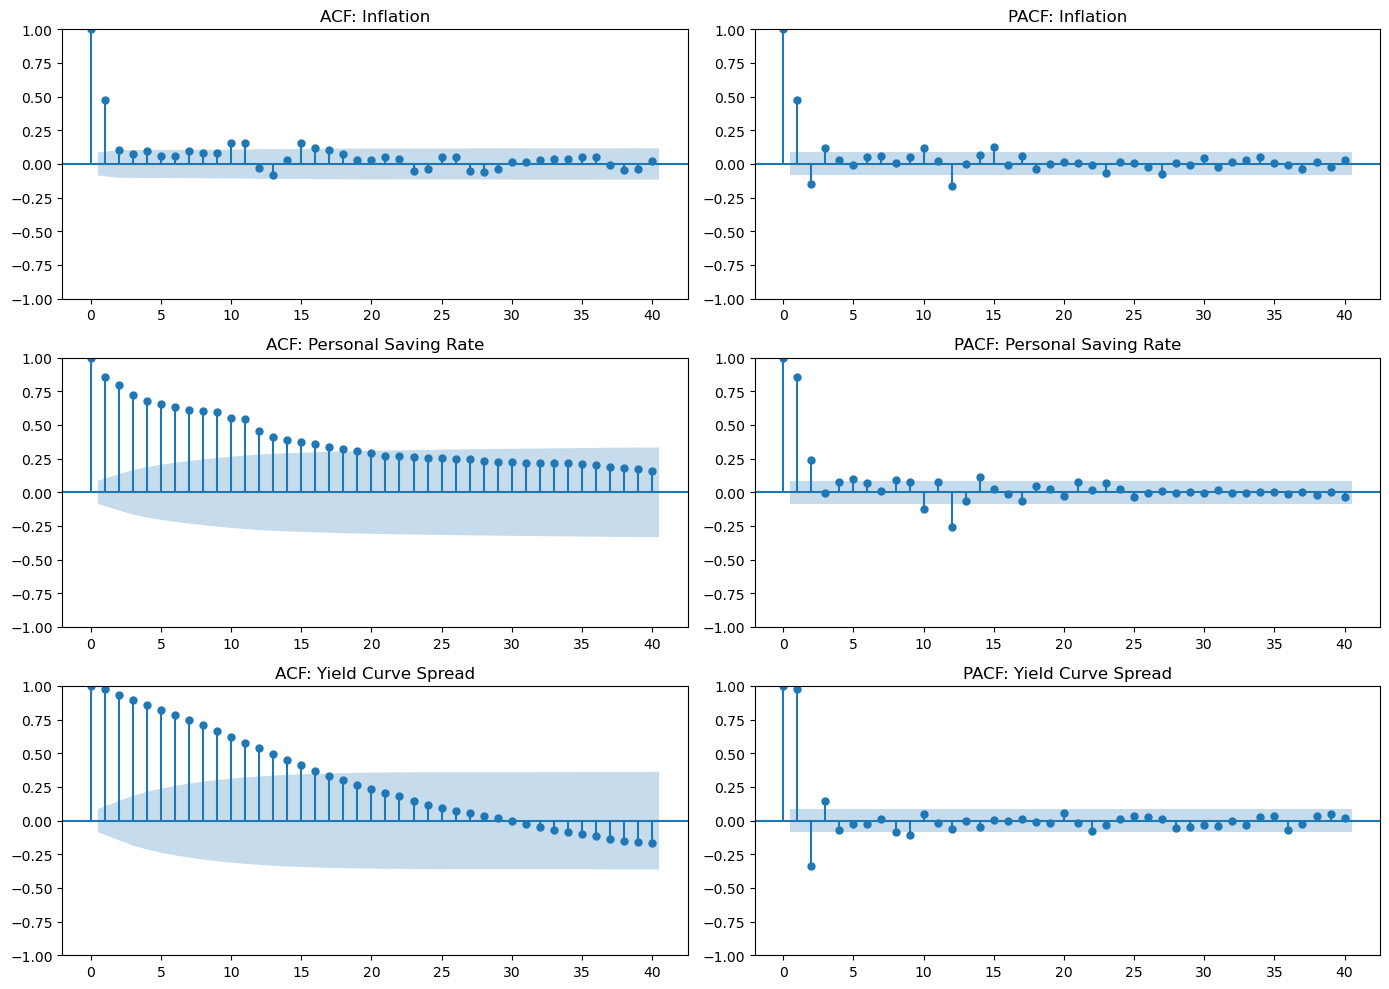

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

series_list = [
    (df_final["Inflation"],  "Inflation"),
    (df_final["PSAVERT"],    "Personal Saving Rate"),
    (df_final["T10Y3M"],     "Yield Curve Spread"),
]

for i, (series, name) in enumerate(series_list):
    plot_acf(series,  ax=axes[i, 0], lags=40, title=f"ACF: {name}")
    plot_pacf(series, ax=axes[i, 1], lags=40, title=f"PACF: {name}")

plt.tight_layout()
plt.show()

Here we have some issues... We see that both the savings rate and the Yield Curve spread are highly persistent... We will address this.

## 3. Local Projections (Jordà 2005)

### 3.1 Setup & Lag Selection

The Local Projection estimator runs a separate OLS regression for each horizon
$h = 0, 1, \ldots, 24$:

$$PSAVERT_{t+h} - PSAVERT_{t-1} = \alpha^h + \beta^h \cdot SHOCK_t + \sum_{l=1}^{p} \gamma_l^h \mathbf{X}_{t-l} + \varepsilon_{t+h}$$

Where:
- The **left side** is the cumulative change in the saving rate between $t-1$ and $t+h$
- $SHOCK_t$ is either the **inversion dummy** (Experiment 1) or the **YC spread level** (Experiment 2)
- $\mathbf{X}_{t-l}$ are lags of all three variables (Inflation, PSAVERT, T10Y3M) included to control for persistence
- $\beta^h$ traced across all horizons gives the **impulse response function (IRF)**
- For Experiment 2, the IRF is scaled by $-10$ to reflect a 10pp decline in the yield curve

The number of lags $p$ is selected by minimising AIC on an VAR in levels.

In [11]:
##############################################################################
# 3.1  AIC-based lag selection
##############################################################################
from statsmodels.tsa.api import VAR
import statsmodels.api as sm

# Build the matrix of variables used in the LP
lp_vars = df_final[["Inflation", "PSAVERT", "T10Y3M"]].copy()

# Fit VAR and select lag order via Information Criteria (max 12 lags is plenty for monthly)
var_model = VAR(lp_vars)
lag_order = var_model.select_order(maxlags=12)

# Switch to BIC for a more parsimonious model
p = lag_order.bic  

print(f"BIC-selected lag order: p = {p}")
print(lag_order.summary())

BIC-selected lag order: p = 2
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        4.825       4.850       124.6       4.835
1      0.01529      0.1145       1.015     0.05416
2      -0.2018   -0.02822*      0.8173    -0.1338*
3      -0.2074     0.04052      0.8127     -0.1103
4      -0.1996      0.1228      0.8191    -0.07322
5      -0.1880      0.2087      0.8286    -0.03253
6      -0.1874      0.2838      0.8292   -0.002679
7      -0.1954      0.3502      0.8227     0.01846
8      -0.1904      0.4295      0.8268     0.05260
9      -0.1913      0.5030      0.8262     0.08086
10     -0.1996      0.5691      0.8194      0.1017
11     -0.1900      0.6531      0.8274      0.1405
12    -0.2560*      0.6615     0.7747*      0.1036
--------------------------------------------------


### 3.2 Build the Regression Dataset

#### 3.2.1. Adding recession dummies

In [12]:
# NBER recession months — add this to df_lp
# Download from FRED: USREC
recession = pd.read_csv(data_path + "USREC.csv")
recession["observation_date"] = pd.to_datetime(recession["observation_date"])

In [13]:
#############################################################################
# 3.2  Construct LP dataset
##############################################################################

H = 36  # maximum horizon

df_lp = df_final[["observation_date", "Inflation", "PSAVERT", "T10Y3M"]].copy()

# --- Experiment 1: Inversion dummy (1 if yield curve is negative) ---
df_lp["D_inversion"] = (df_lp["T10Y3M"] < 0).astype(int)

# --- ADD HERE: COVID dummy and recession merge ---
df_lp["D_covid"] = ((df_lp["observation_date"] >= "2020-03-01") & 
                    (df_lp["observation_date"] <= "2021-06-01")).astype(int)

# Recession dummies

recession = pd.read_csv(data_path + "USREC.csv")
recession["observation_date"] = pd.to_datetime(recession["observation_date"])
df_lp = df_lp.merge(recession, on="observation_date", how="left")
df_lp.rename(columns={"USREC": "D_recession"}, inplace=True)

# --- Lag matrix: p lags of all three variables ---
for lag in range(1, p + 1):
    df_lp[f"Inflation_L{lag}"]  = df_lp["Inflation"].shift(lag)
    df_lp[f"PSAVERT_L{lag}"]    = df_lp["PSAVERT"].shift(lag)
    df_lp[f"T10Y3M_L{lag}"]     = df_lp["T10Y3M"].shift(lag)

# --- Outcome variables: cumulative change in PSAVERT at each horizon h ---
# PSAVERT_{t+h} - PSAVERT_{t-1}
df_lp["PSAVERT_Lminus1"] = df_lp["PSAVERT_L1"] 

for h in range(0, H + 1):
    df_lp[f"y_h{h}"] = df_lp["PSAVERT"].shift(-h) - df_lp["PSAVERT_Lminus1"]

df_lp = df_lp.dropna().reset_index(drop=True)

print(f"LP dataset shape after dropping NAs: {df_lp.shape}")
df_lp.head()

LP dataset shape after dropping NAs: (487, 51)


,observation_date,Inflation,PSAVERT,T10Y3M,D_inversion,D_covid,D_recession,Inflation_L1,PSAVERT_L1,T10Y3M_L1,...,y_h27,y_h28,y_h29,y_h30,y_h31,y_h32,y_h33,y_h34,y_h35,y_h36
0,1982-04-01,3.795470,12.8,0.527143,0,0,1,0.000000,12.1,0.546522,...,-0.7,-0.4,-0.4,-0.5,-1.4,-1.0,-1.9,-3.2,-3.5,-2.3
1,1982-05-01,11.314908,12.2,0.908500,0,0,1,3.795470,12.8,0.527143,...,-1.1,-1.1,-1.2,-2.1,-1.7,-2.6,-3.9,-4.2,-3.0,-1.8
2,1982-06-01,13.685996,12.2,1.220909,0,0,1,11.314908,12.2,0.908500,...,-0.5,-0.6,-1.5,-1.1,-2.0,-3.3,-3.6,-2.4,-1.2,-2.6
3,1982-07-01,6.169679,12.5,2.082857,0,0,1,13.685996,12.2,1.220909,...,-0.6,-1.5,-1.1,-2.0,-3.3,-3.6,-2.4,-1.2,-2.6,-3.1
4,1982-08-01,2.459017,12.5,4.057727,0,0,1,6.169679,12.5,2.082857,...,-1.8,-1.4,-2.3,-3.6,-3.9,-2.7,-1.5,-2.9,-3.4,-4.4


### 3.3 Run Local Projections

In [14]:
##############################################################################
# 3.3  Local Projection regressions — one per horizon h
##############################################################################

# Lags are still required to soak up the persistence
lag_cols = [f"Inflation_L{l}"  for l in range(1, p + 1)] + \
           [f"PSAVERT_L{l}"    for l in range(1, p + 1)] + \
           [f"T10Y3M_L{l}"     for l in range(1, p + 1)]

# CHOLESKY CONTROLS + COVID Dummy: 
# Because T10Y3M / Inversion is ordered LAST (fast-moving financial variable), 
# we must control for the contemporaneous (time t) values of the slower variables.
# Also added a Covid Dummy...

contemp_controls = ["PSAVERT", "Inflation"]  # Cholesky controls

outlier_controls = ["D_covid", "D_recession"] # COVID control, recession controls

results_exp1 = []   # Inversion dummy
results_exp2 = []   # YC level (1pp decline)

for h in range(0, H + 1):
    y = df_lp[f"y_h{h}"]

    # --- Experiment 1: Inversion dummy ---
    # Add contemp_controls alongside the shock and lags
    cols1 = ["D_inversion"] + contemp_controls + outlier_controls + lag_cols
    X1 = sm.add_constant(df_lp[cols1])
    
    model1 = sm.OLS(y, X1).fit(cov_type="HC1")  
    coef1 = model1.params["D_inversion"]
    # ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"] # ALPHA = 0.05%
    ci1 = model1.conf_int(alpha=0.10).loc["D_inversion"] ## alpha = 10% !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    results_exp1.append({"h": h, "coef": coef1, "ci_low": ci1[0], "ci_high": ci1[1]})

    # --- Experiment 2: YC level, scaled by -1 for a 1pp (100 bps) decline ---
    # Add contemp_controls alongside the shock and lags
    cols2 = ["T10Y3M"]      + contemp_controls + outlier_controls + lag_cols
    X2 = sm.add_constant(df_lp[cols2])
    
    model2 = sm.OLS(y, X2).fit(cov_type="HC1")
    coef2 = model2.params["T10Y3M"]
    # ci2 = m2.conf_int(alpha=0.10).loc["T10Y3M"] # ALPHA = 0.05%
    ci2 = model2.conf_int(alpha=0.10).loc["T10Y3M"] ## alpha = 10% !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
    
    # Scale by -1 (a 1 percentage point flattening of the yield curve)
    shock_size = -1 
    results_exp2.append({
        "h": h, 
        "coef": coef2 * shock_size, 
        "ci_low": ci2[0] * shock_size, 
        "ci_high": ci2[1] * shock_size
    })

irf1 = pd.DataFrame(results_exp1)
irf2 = pd.DataFrame(results_exp2)

# Fix CI ordering after negative multiplication
irf2["ci_low"], irf2["ci_high"] = irf2[["ci_low","ci_high"]].min(axis=1), irf2[["ci_low","ci_high"]].max(axis=1)

print("Experiment 2 (1pp Yield Curve Flattening) IRF:")
print(irf2.round(4))

Experiment 2 (1pp Yield Curve Flattening) IRF:
     h    coef  ci_low  ci_high
0    0 -0.0000 -0.0000   0.0000
1    1 -0.4666 -1.1687   0.2354
2    2 -0.1757 -0.7921   0.4407
3    3  0.0433 -0.4853   0.5719
4    4 -0.0182 -0.5160   0.4796
5    5 -0.1163 -0.5764   0.3439
6    6 -0.3117 -0.8147   0.1913
7    7 -0.3607 -0.9136   0.1923
8    8 -0.0622 -0.7740   0.6496
9    9  0.1495 -0.4592   0.7581
10  10  0.0254 -0.7167   0.7675
11  11  0.2916 -0.3457   0.9290
12  12 -0.2401 -1.1246   0.6445
13  13  0.1684 -0.5139   0.8507
14  14 -0.0269 -0.6371   0.5834
15  15  0.2172 -0.3267   0.7611
16  16  0.3136 -0.3943   1.0215
17  17  0.2396 -0.4225   0.9017
18  18  0.2067 -0.3556   0.7689
19  19  0.4504 -0.1759   1.0768
20  20  0.1364 -0.3593   0.6322
21  21  0.3462 -0.1615   0.8538
22  22  0.4379 -0.0754   0.9512
23  23  0.2948 -0.1900   0.7796
24  24  0.3949 -0.1232   0.9131
25  25  0.3046 -0.2461   0.8554
26  26  0.1198 -0.4055   0.6450
27  27  0.3057 -0.2506   0.8619
28  28  0.2825 -0.2154   

### 3.4 Plot Impulse Response Functions

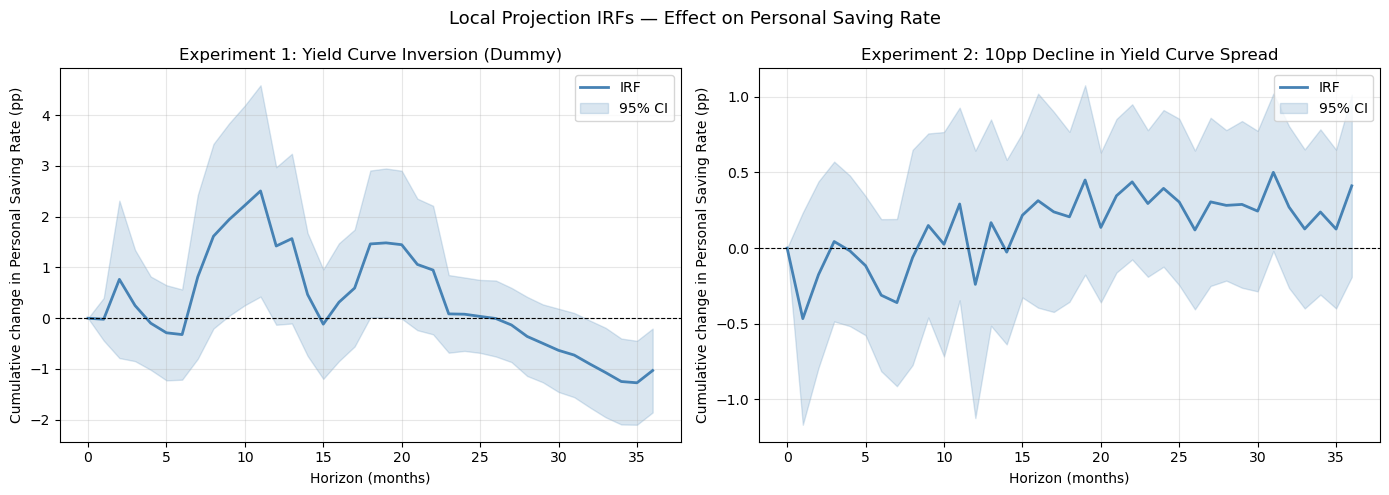

In [15]:
##############################################################################
# 3.4  IRF Plots
##############################################################################

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, irf, title, shock_label in zip(
    axes,
    [irf1, irf2],
    ["Experiment 1: Yield Curve Inversion (Dummy)",
     "Experiment 2: 10pp Decline in Yield Curve Spread"],
    ["Inversion dummy = 1", "10pp decline in T10Y3M"]
):
    ax.plot(irf["h"], irf["coef"], color="steelblue", linewidth=2, label="IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.2, color="steelblue", label="95% CI")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumulative change in Personal Saving Rate (pp)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Local Projection IRFs — Effect on Personal Saving Rate", fontsize=13)
plt.tight_layout()
plt.show()

### 3.5  Local Projections — Three Model Variants

In [16]:
##############################################################################
# 3.5  Local Projections — Four Model Variants
##############################################################################
# Model 1: HC1 SEs, full sample
# Model 2: Newey-West (HAC) SEs, full sample
# Model 3: Newey-West (HAC) SEs, pre-2020 sample
# Model 4: HC1 SEs, pre-2020 sample

import statsmodels.api as sm

# --- Recession control: download USREC from FRED and merge ---

recession = pd.read_csv(data_path + "USREC.csv")
recession["observation_date"] = pd.to_datetime(recession["observation_date"])
df_lp = df_lp.merge(recession, on="observation_date", how="left")
df_lp.rename(columns={"USREC": "D_recession"}, inplace=True)

# --- Shared setup ---
lag_cols = [f"Inflation_L{l}" for l in range(1, p + 1)] + \
           [f"PSAVERT_L{l}"   for l in range(1, p + 1)] + \
           [f"T10Y3M_L{l}"    for l in range(1, p + 1)]

# Cholesky controls: contemporaneous values of variables ordered before the shock
contemp_controls = ["PSAVERT", "Inflation"]

# Outlier/trend controls: COVID dummy, linear trend, recession dummy
outlier_controls = ["D_covid", "trend", "D_recession"]

# --- Pre-2020 dataset for Models 3 & 4 ---
# Note: D_covid and D_recession are automatically dropped by the column filter
# inside run_lp() since pre-2020 data has no COVID observations
df_lp_pre2020 = df_lp[df_lp["observation_date"] < "2020-01-01"].copy().reset_index(drop=True)

print(f"Full sample:     {len(df_lp)} observations")
print(f"Pre-2020 sample: {len(df_lp_pre2020)} observations")


# --- Helper function: runs LP for one dataset and SE type ---
def run_lp(data, se_type, H=36):
    """
    Runs a Local Projection for each horizon h = 0, ..., H.

    For each h, estimates:
        PSAVERT_{t+h} - PSAVERT_{t-1} = a + b*SHOCK_t + contemp + outlier + lags + e

    se_type: "HC1" for heteroskedasticity-robust
             "HAC" for Newey-West (accounts for serial correlation in overlapping residuals)

    Returns: irf1 (inversion dummy IRF), irf2 (1pp YC decline IRF)
    """
    res1, res2 = [], []

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        # SE kwargs
        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else:
            # maxlags = h+1 follows the LP literature convention (Jordà 2005)
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}}

        # --- Experiment 1: Inversion dummy ---
        cols1 = ["D_inversion"] + contemp_controls + outlier_controls + lag_cols
        cols1 = [c for c in cols1 if c in data.columns]  # drop missing cols (pre-2020)
        X1 = sm.add_constant(data[cols1])
        m1 = sm.OLS(y, X1).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h":       h,
                     "coef":    m1.params["D_inversion"],
                     "ci_low":  ci1[0],
                     "ci_high": ci1[1]})

        # --- Experiment 2: 1pp decline in YC spread ---
        cols2 = ["T10Y3M"] + contemp_controls + outlier_controls + lag_cols
        cols2 = [c for c in cols2 if c in data.columns]
        X2 = sm.add_constant(data[cols2])
        m2 = sm.OLS(y, X2).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2 = m2.conf_int(alpha=0.10).loc["T10Y3M"]

        shock = -1  # 1pp flattening of the yield curve
        res2.append({"h":       h,
                     "coef":    coef2 * shock,
                     "ci_low":  ci2[0] * shock,
                     "ci_high": ci2[1] * shock})

    irf1 = pd.DataFrame(res1)
    irf2 = pd.DataFrame(res2)

    # Fix CI ordering after negative multiplication in Exp 2
    irf2["ci_low"], irf2["ci_high"] = (irf2[["ci_low", "ci_high"]].min(axis=1),
                                        irf2[["ci_low", "ci_high"]].max(axis=1))
    return irf1, irf2


# --- Run all four models ---
irf1_m1, irf2_m1 = run_lp(df_lp,         se_type="HC1")  # Model 1
irf1_m2, irf2_m2 = run_lp(df_lp,         se_type="HAC")  # Model 2
irf1_m3, irf2_m3 = run_lp(df_lp_pre2020, se_type="HAC")  # Model 3
irf1_m4, irf2_m4 = run_lp(df_lp_pre2020, se_type="HC1")  # Model 4

print("All four models estimated successfully.")

Full sample:     487 observations
Pre-2020 sample: 453 observations
All four models estimated successfully.


### 3.6  Plot — one figure per experiment, all three models overlaid

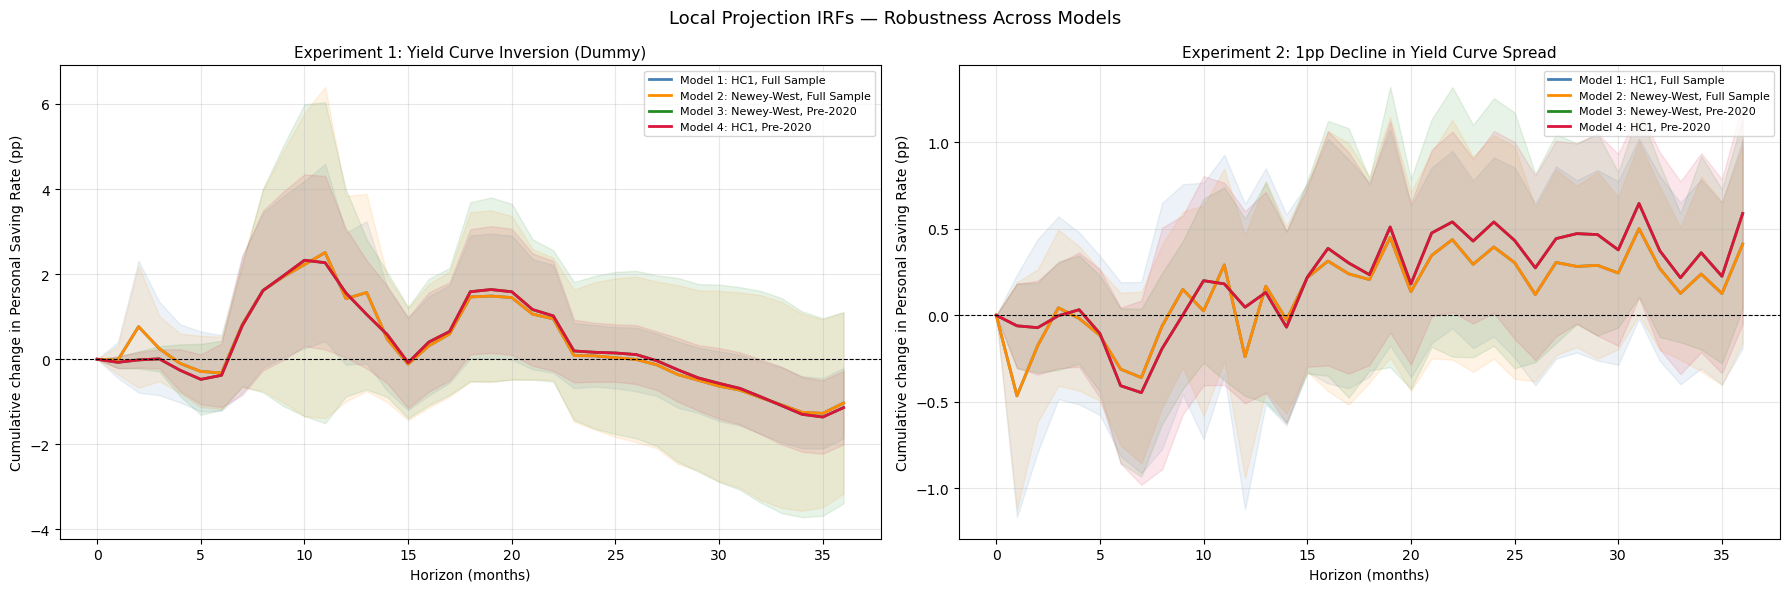

In [17]:
##############################################################################
# 3.6  Plot — all four models overlaid, one panel per experiment
##############################################################################

model_specs = [
    (irf1_m1, irf2_m1, "Model 1: HC1, Full Sample",         "steelblue"),
    (irf1_m2, irf2_m2, "Model 2: Newey-West, Full Sample",  "darkorange"),
    (irf1_m3, irf2_m3, "Model 3: Newey-West, Pre-2020",     "forestgreen"),
    (irf1_m4, irf2_m4, "Model 4: HC1, Pre-2020",            "crimson"),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

exp_titles = [
    "Experiment 1: Yield Curve Inversion (Dummy)",
    "Experiment 2: 1pp Decline in Yield Curve Spread"
]

for col, (ax, title) in enumerate(zip(axes, exp_titles)):
    for irf1, irf2, label, color in model_specs:
        irf = irf1 if col == 0 else irf2
        ax.plot(irf["h"], irf["coef"],
                color=color, linewidth=2, label=label)
        ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                        alpha=0.10, color=color)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumulative change in Personal Saving Rate (pp)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Local Projection IRFs — Robustness Across Models", fontsize=13)
plt.tight_layout()
plt.show()

### 3.7  Summary Tables — IRF Coefficients Across All Four Models

In [18]:
##############################################################################
# 3.7  Summary Tables — IRF Coefficients Across All Four Models
##############################################################################

def make_summary_table(irfs, model_names, experiment_name):
    """
    Combines IRF results from multiple models into a single readable table.
    Columns: horizon, then for each model: coef, ci_low, ci_high
    """
    rows = []
    for h in range(len(irfs[0])):
        row = {"Horizon": h}
        for irf, name in zip(irfs, model_names):
            short = name.replace("Model ", "M").split(":")[0].strip()
            row[f"{short} coef"]     = round(irf.loc[h, "coef"],    3)
            row[f"{short} ci_low"]   = round(irf.loc[h, "ci_low"],  3)
            row[f"{short} ci_high"]  = round(irf.loc[h, "ci_high"], 3)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("Horizon")
    print(f"\n{'='*80}")
    print(f"  {experiment_name}")
    print(f"{'='*80}")
    print(df.to_string())
    return df

model_names = [
    "Model 1: HC1, Full Sample",
    "Model 2: Newey-West, Full Sample",
    "Model 3: Newey-West, Pre-2020",
    "Model 4: HC1, Pre-2020",
]

# --- Experiment 1: Inversion Dummy ---
table_exp1 = make_summary_table(
    irfs         = [irf1_m1, irf1_m2, irf1_m3, irf1_m4],
    model_names  = model_names,
    experiment_name = "Experiment 1: Yield Curve Inversion (Dummy)"
)

# --- Experiment 2: 1pp Decline in YC Spread ---
table_exp2 = make_summary_table(
    irfs         = [irf2_m1, irf2_m2, irf2_m3, irf2_m4],
    model_names  = model_names,
    experiment_name = "Experiment 2: 1pp Decline in Yield Curve Spread"
)


  Experiment 1: Yield Curve Inversion (Dummy)
         M1 coef  M1 ci_low  M1 ci_high  M2 coef  M2 ci_low  M2 ci_high  M3 coef  M3 ci_low  M3 ci_high  M4 coef  M4 ci_low  M4 ci_high
Horizon                                                                                                                                
0          0.000     -0.000       0.000    0.000     -0.000       0.000    0.000      0.000       0.000    0.000      0.000       0.000
1         -0.020     -0.440       0.399   -0.020     -0.352       0.312   -0.073     -0.207       0.062   -0.073     -0.212       0.067
2          0.766     -0.785       2.316    0.766     -0.671       2.202   -0.016     -0.217       0.185   -0.016     -0.197       0.165
3          0.250     -0.845       1.345    0.250     -0.516       1.016    0.009     -0.285       0.302    0.009     -0.215       0.233
4         -0.098     -1.017       0.821   -0.098     -0.797       0.601   -0.258     -0.866       0.350   -0.258     -0.752       0.236
5

### 3.8 Model 1 & Model 4 :)


  Experiment 1: Yield Curve Inversion (Dummy)
  Model 1: HC1 SEs, Full Sample | Model 4: HC1 SEs, Pre-2020
  90% Confidence Intervals | ✓ = significant at 10% level
         M1 coef  M1 ci_low  M1 ci_high M1 sig  M4 coef  M4 ci_low  M4 ci_high M4 sig
Horizon                                                                              
0          0.000     -0.000       0.000           0.000      0.000       0.000      ✓
1         -0.020     -0.440       0.399          -0.073     -0.212       0.067       
2          0.766     -0.785       2.316          -0.016     -0.197       0.165       
3          0.250     -0.845       1.345           0.009     -0.215       0.233       
4         -0.098     -1.017       0.821          -0.258     -0.752       0.236       
5         -0.287     -1.224       0.651          -0.473     -1.060       0.114       
6         -0.322     -1.211       0.567          -0.377     -1.125       0.370       
7          0.816     -0.798       2.430           0.788     

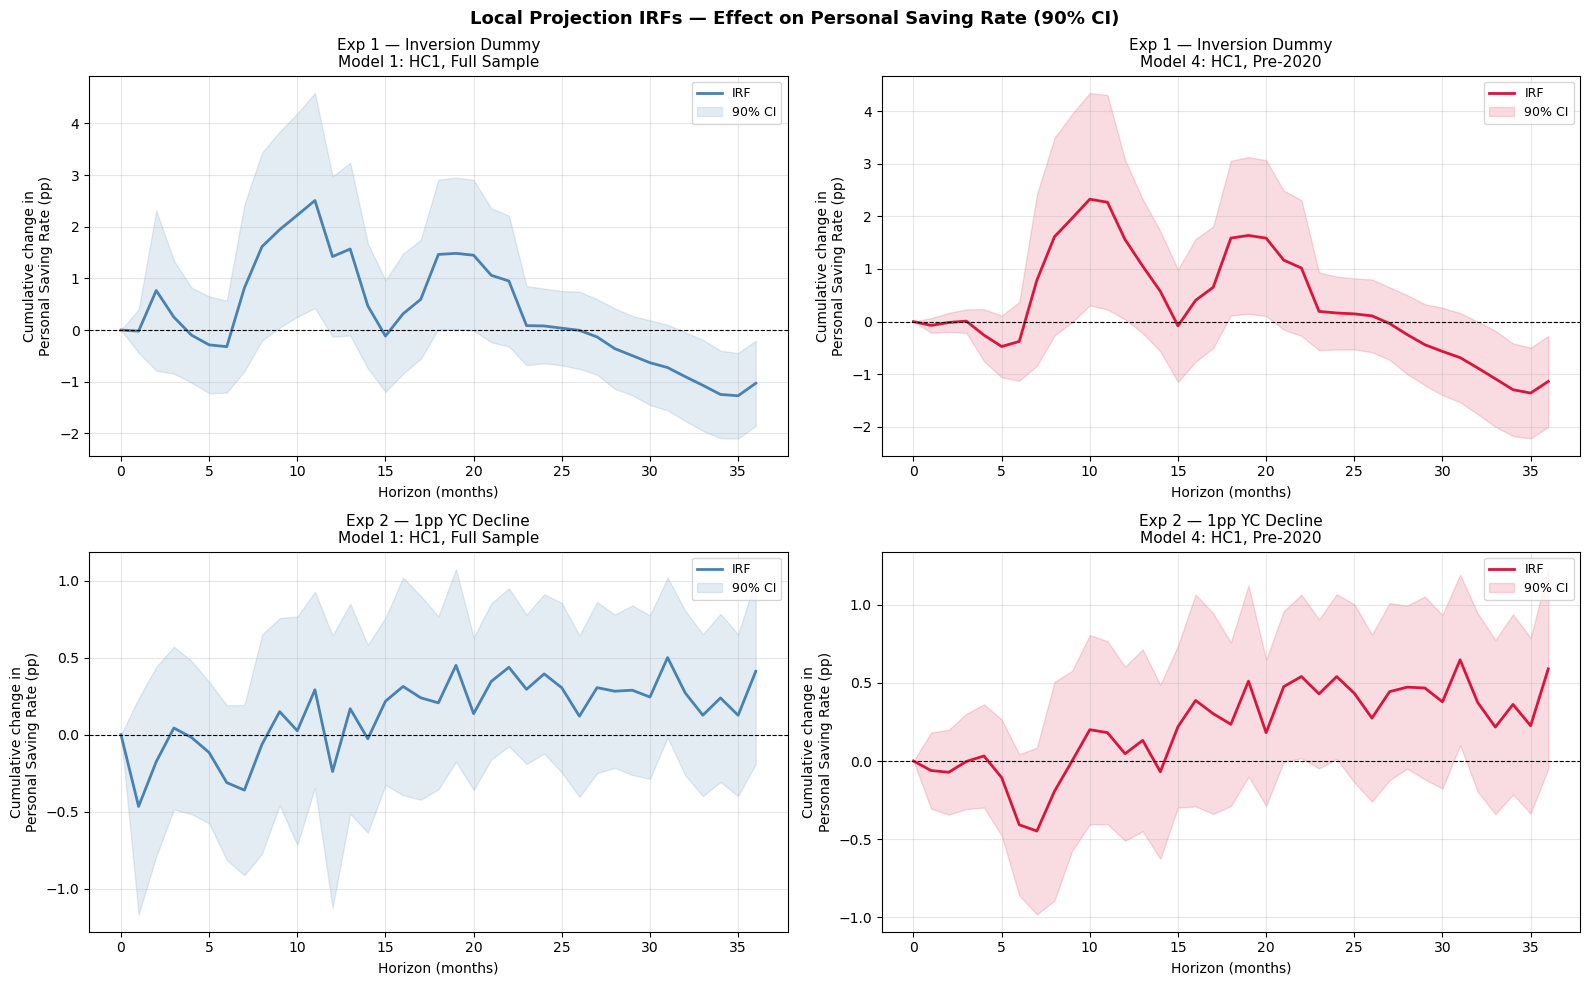

In [19]:
# --- Summary Table ---

def make_final_table(irf_m1, irf_m4, experiment_name):
    rows = []
    for h in range(len(irf_m1)):
        rows.append({
            "Horizon"       : h,
            "M1 coef"       : round(irf_m1.loc[h, "coef"],    3),
            "M1 ci_low"     : round(irf_m1.loc[h, "ci_low"],  3),
            "M1 ci_high"    : round(irf_m1.loc[h, "ci_high"], 3),
            "M1 sig"        : "✓" if irf_m1.loc[h, "ci_low"] > 0 or irf_m1.loc[h, "ci_high"] < 0 else "",
            "M4 coef"       : round(irf_m4.loc[h, "coef"],    3),
            "M4 ci_low"     : round(irf_m4.loc[h, "ci_low"],  3),
            "M4 ci_high"    : round(irf_m4.loc[h, "ci_high"], 3),
            "M4 sig"        : "✓" if irf_m4.loc[h, "ci_low"] > 0 or irf_m4.loc[h, "ci_high"] < 0 else "",
        })
    df = pd.DataFrame(rows).set_index("Horizon")
    print(f"\n{'='*80}")
    print(f"  {experiment_name}")
    print(f"  Model 1: HC1 SEs, Full Sample | Model 4: HC1 SEs, Pre-2020")
    print(f"  90% Confidence Intervals | ✓ = significant at 10% level")
    print(f"{'='*80}")
    print(df.to_string())
    return df

table1_final = make_final_table(irf1_m1, irf1_m4,
                                 "Experiment 1: Yield Curve Inversion (Dummy)")
table2_final = make_final_table(irf2_m1, irf2_m4,
                                 "Experiment 2: 1pp Decline in Yield Curve Spread")


# --- IRF Plot: Model 1 and Model 4 side by side ---

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

specs = [
    # (irf,      title,                                    color,        ax)
    (irf1_m1, "Exp 1 — Inversion Dummy\nModel 1: HC1, Full Sample",    "steelblue", axes[0, 0]),
    (irf1_m4, "Exp 1 — Inversion Dummy\nModel 4: HC1, Pre-2020",       "crimson",   axes[0, 1]),
    (irf2_m1, "Exp 2 — 1pp YC Decline\nModel 1: HC1, Full Sample",     "steelblue", axes[1, 0]),
    (irf2_m4, "Exp 2 — 1pp YC Decline\nModel 4: HC1, Pre-2020",        "crimson",   axes[1, 1]),
]

for irf, title, color, ax in specs:
    ax.plot(irf["h"], irf["coef"],
            color=color, linewidth=2, label="IRF")
    ax.fill_between(irf["h"], irf["ci_low"], irf["ci_high"],
                    alpha=0.15, color=color, label="90% CI")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Horizon (months)")
    ax.set_ylabel("Cumulative change in\nPersonal Saving Rate (pp)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Local Projection IRFs — Effect on Personal Saving Rate (90% CI)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.9 Coefficient checks

In [20]:
##############################################################################
# 3.9  Significance Tests — P-values, F-tests, and Robustness Checks
##############################################################################

import statsmodels.api as sm
from scipy import stats

# --- Helper: runs LP and returns full model objects (not just IRF summaries) ---
def run_lp_full(data, se_type, H=24):
    """
    Same as run_lp() but also returns the full OLS result objects
    so we can extract p-values and run F-tests.
    """
    res1, res2       = [], []
    models1, models2 = [], []

    for h in range(0, H + 1):
        y = data[f"y_h{h}"]

        if se_type == "HC1":
            fit_kwargs = {"cov_type": "HC1"}
        else:
            fit_kwargs = {"cov_type": "HAC", "cov_kwds": {"maxlags": h + 1}}

        # Experiment 1
        cols1 = ["D_inversion"] + contemp_controls + outlier_controls + lag_cols
        cols1 = [c for c in cols1 if c in data.columns]
        X1 = sm.add_constant(data[cols1])
        m1 = sm.OLS(y, X1).fit(**fit_kwargs)
        ci1 = m1.conf_int(alpha=0.10).loc["D_inversion"]
        res1.append({"h": h, "coef": m1.params["D_inversion"],
                     "ci_low": ci1[0], "ci_high": ci1[1],
                     "pval": m1.pvalues["D_inversion"]})
        models1.append(m1)

        # Experiment 2
        cols2 = ["T10Y3M"] + contemp_controls + outlier_controls + lag_cols
        cols2 = [c for c in cols2 if c in data.columns]
        X2 = sm.add_constant(data[cols2])
        m2 = sm.OLS(y, X2).fit(**fit_kwargs)
        coef2 = m2.params["T10Y3M"]
        ci2   = m2.conf_int(alpha=0.10).loc["T10Y3M"]
        shock = -1
        res2.append({"h": h, "coef": coef2 * shock,
                     "ci_low":  min(ci2[0] * shock, ci2[1] * shock),
                     "ci_high": max(ci2[0] * shock, ci2[1] * shock),
                     "pval": m2.pvalues["T10Y3M"]})
        models2.append(m2)

    return pd.DataFrame(res1), pd.DataFrame(res2), models1, models2


# --- Run for Model 1 and Model 4 ---
irf1_m1_full, irf2_m1_full, mods1_m1, mods2_m1 = run_lp_full(df_lp,         "HC1")
irf1_m4_full, irf2_m4_full, mods1_m4, mods2_m4 = run_lp_full(df_lp_pre2020, "HC1")


##############################################################################
# A. Individual P-value Tables
##############################################################################

def pval_stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

def make_pval_table(irf1, irf4, experiment_name):
    rows = []
    for h in range(len(irf1)):
        rows.append({
            "Horizon"   : h,
            "M1 coef"   : round(irf1.loc[h, "coef"], 3),
            "M1 p-val"  : round(irf1.loc[h, "pval"], 3),
            "M1 sig"    : pval_stars(irf1.loc[h, "pval"]),
            "M4 coef"   : round(irf4.loc[h, "coef"], 3),
            "M4 p-val"  : round(irf4.loc[h, "pval"], 3),
            "M4 sig"    : pval_stars(irf4.loc[h, "pval"]),
        })
    df = pd.DataFrame(rows).set_index("Horizon")
    print(f"\n{'='*70}")
    print(f"  {experiment_name}")
    print(f"  Significance: * p<0.10  ** p<0.05  *** p<0.01")
    print(f"{'='*70}")
    print(df.to_string())
    return df

pval_exp1 = make_pval_table(irf1_m1_full, irf1_m4_full,
                             "Experiment 1: Yield Curve Inversion (Dummy)")
pval_exp2 = make_pval_table(irf2_m1_full, irf2_m4_full,
                             "Experiment 2: 1pp Decline in Yield Curve Spread")


##############################################################################
# B. Joint F-test: Are ALL IRF coefficients jointly zero?
##############################################################################
# This tests the global null: β^h = 0 for ALL h simultaneously.
# We stack all horizon regressions and test jointly using an F-statistic.

def joint_f_test(models, shock_var, label):
    """
    Extracts the t-stat from each horizon and computes a joint chi-squared test
    by summing squared t-statistics (approximate, assumes independence across h).
    Also reports the Wald test from each model individually.
    """
    print(f"\n{'='*70}")
    print(f"  Joint Significance Test: {label}")
    print(f"  H0: IRF coefficient = 0 at ALL horizons simultaneously")
    print(f"{'='*70}")

    t_stats = []
    p_vals  = []
    for h, m in enumerate(models):
        t = m.tvalues[shock_var]
        p = m.pvalues[shock_var]
        t_stats.append(t)
        p_vals.append(p)

    # Chi-squared approximation: sum of squared t-stats ~ chi2(H+1) under H0
    H       = len(models)
    chi2    = sum(t**2 for t in t_stats)
    p_joint = 1 - stats.chi2.cdf(chi2, df=H)

    print(f"  Number of horizons tested : {H}")
    print(f"  Sum of squared t-stats    : {chi2:.3f}")
    print(f"  Degrees of freedom        : {H}")
    print(f"  Joint p-value (chi2 approx): {p_joint:.4f}")

    if p_joint < 0.01:
        conclusion = "Reject H0 at 1% — IRF is jointly significant ***"
    elif p_joint < 0.05:
        conclusion = "Reject H0 at 5% — IRF is jointly significant **"
    elif p_joint < 0.10:
        conclusion = "Reject H0 at 10% — IRF is jointly significant *"
    else:
        conclusion = "Fail to reject H0 — IRF is NOT jointly significant"
    print(f"  Conclusion: {conclusion}")

    # Also show which horizons are individually most significant
    top3 = sorted(enumerate(p_vals), key=lambda x: x[1])[:3]
    print(f"\n  Three most significant individual horizons:")
    for h, p in top3:
        print(f"    h={h:2d}  t={t_stats[h]:+.3f}  p={p:.3f} {pval_stars(p)}")

# Model 1
joint_f_test(mods1_m1, "D_inversion", "Exp 1 — Inversion Dummy, Model 1 (Full Sample)")
joint_f_test(mods2_m1, "T10Y3M",      "Exp 2 — YC Spread, Model 1 (Full Sample)")

# Model 4
joint_f_test(mods1_m4, "D_inversion", "Exp 1 — Inversion Dummy, Model 4 (Pre-2020)")
joint_f_test(mods2_m4, "T10Y3M",      "Exp 2 — YC Spread, Model 4 (Pre-2020)")


##############################################################################
# C. Additional Robustness Checks
##############################################################################
# The following checks are standard in the LP literature and address the most
# common referee concerns. Each is flagged with what it tests and how to run it.

print("""
================================================================================
  ROBUSTNESS CHECKLIST — What else should you check?
================================================================================

DONE ✅
-------
[✅] HC1 heteroskedasticity-robust standard errors
[✅] Newey-West (HAC) standard errors for serial correlation
[✅] COVID dummy to absorb pandemic outlier
[✅] NBER recession dummy as control
[✅] Linear trend to control for secular decline in saving rate
[✅] Cholesky ordering (contemp controls for PSAVERT and Inflation)
[✅] Pre-2020 subsample robustness
[✅] BIC lag selection
[✅] Both binary (dummy) and continuous (spread level) shock definitions
[✅] 90% confidence intervals (standard in LP literature)
[✅] Joint F-test for global IRF significance

RECOMMENDED — HIGH PRIORITY ⚠️
---------------------------------
[⚠️] Lag sensitivity: Re-run with p=1, p=3, p=6 and compare IRFs.
     If results hold across lag choices, you have a stronger robustness case.
     Code: change p=1 in run_lp_full() and compare irf plots.

[⚠️] Placebo test: Replace D_inversion with a RANDOMLY SHUFFLED version.
     If the shuffled IRF is also 'significant', your result is spurious.
     Code: df_lp['D_placebo'] = df_lp['D_inversion'].sample(frac=1).values

[⚠️] Alternative outcome: Run the LP with Inflation as the outcome variable
     instead of PSAVERT. If the yield curve predicts saving but not inflation,
     that supports the precautionary saving channel over the monetary channel.

RECOMMENDED — MEDIUM PRIORITY 📋
----------------------------------
[📋] Rolling window estimation: Run the LP on a 20-year rolling window
     to check if the effect has changed over time (pre/post-GFC split).

[📋] Alternative shock definition: Use the FIRST DIFFERENCE of T10Y3M
     instead of the level as your shock in Experiment 2. This captures
     the change in the spread rather than its level.

[📋] Heterogeneity: If you can get state-level data, a panel LP would
     give you far more identification power than the aggregate time series.

OPTIONAL — FOR COMPLETENESS 📝
--------------------------------
[📝] Report R-squared at each horizon h (should rise then fall — a good sign)
[📝] Plot residuals from h=10 regression to visually check for outliers
[📝] Formally test for structural break around 2008 (Chow test)
""")


  Experiment 1: Yield Curve Inversion (Dummy)
  Significance: * p<0.10  ** p<0.05  *** p<0.01
         M1 coef  M1 p-val M1 sig  M4 coef  M4 p-val M4 sig
Horizon                                                    
0          0.000     0.871           0.000     0.000    ***
1         -0.020     0.937          -0.073     0.392       
2          0.766     0.416          -0.016     0.883       
3          0.250     0.707           0.009     0.948       
4         -0.098     0.861          -0.258     0.390       
5         -0.287     0.615          -0.473     0.185       
6         -0.322     0.552          -0.377     0.407       
7          0.816     0.406           0.788     0.426       
8          1.616     0.144           1.614     0.157       
9          1.944     0.092      *    1.966     0.102       
10         2.224     0.063      *    2.326     0.058      *
11         2.508     0.048     **    2.269     0.067      *
12         1.423     0.131           1.558     0.091      *
13   

## 4. Results Exports

In [25]:
##############################################################################
# 4.  Export Results — Academic LaTeX Tables
##############################################################################

from scipy import stats
import os

output_path = r"C:\Users\cufa9\Documents\Master\UdeSA\Tesis"

# --- Helper: format coefficient with stars ---
def fmt(coef, pval, decimals=3):
    stars = ""
    if pval < 0.01:
        stars = "***"
    elif pval < 0.05:
        stars = "**"
    elif pval < 0.10:
        stars = "*"
    return f"{coef:.{decimals}f}{stars}"

def fmt_se(ci_low, ci_high):
    return f"[{ci_low:.3f}, {ci_high:.3f}]"


##############################################################################
# Table 1: IRF Coefficients
##############################################################################

def make_latex_irf_table(irf1, irf4, exp_label, shock_label, filename):
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append("\\caption{Impulse Response Functions: " + exp_label + "}")
    lines.append("\\label{tab:irf_" + filename + "}")
    lines.append(r"\begin{tabular}{c cccc}")
    lines.append(r"\toprule")
    lines.append(r" & \multicolumn{2}{c}{\textbf{Model 1}} & \multicolumn{2}{c}{\textbf{Model 4}} \\")
    lines.append(r" & \multicolumn{2}{c}{HC1 SEs, Full Sample} & \multicolumn{2}{c}{HC1 SEs, Pre-2020} \\")
    lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
    lines.append(r"\textbf{Horizon} & \textbf{Coef.} & \textbf{90\% CI} & \textbf{Coef.} & \textbf{90\% CI} \\")
    lines.append(r"\midrule")

    for h in range(1, len(irf1)):
        r1    = irf1.loc[h]
        r4    = irf4.loc[h]
        coef1 = fmt(r1["coef"], r1["pval"])
        ci1   = fmt_se(r1["ci_low"], r1["ci_high"])
        coef4 = fmt(r4["coef"], r4["pval"])
        ci4   = fmt_se(r4["ci_low"], r4["ci_high"])

        sig        = r1["pval"] < 0.10 or r4["pval"] < 0.10
        bold_open  = "\\textbf{" if sig else ""
        bold_close = "}"         if sig else ""
        row = bold_open + str(h) + bold_close + " & " + coef1 + " & " + ci1 + " & " + coef4 + " & " + ci4 + " \\\\"
        lines.append(row)

    lines.append(r"\midrule")
    lines.append(r"\multicolumn{5}{l}{\textit{Notes:} Dependent variable: cumulative change in Personal Saving Rate (pp).} \\")
    lines.append(r"\multicolumn{5}{l}{Shock: " + shock_label + r". Horizons h=1 to h=24. h=0 excluded (Cholesky impact artifact).} \\")
    lines.append(r"\multicolumn{5}{l}{Controls: contemporaneous PSAVERT and Inflation (Cholesky), COVID dummy,} \\")
    lines.append(r"\multicolumn{5}{l}{NBER recession dummy, linear trend, " + str(p) + r" BIC-selected lags.} \\")
    lines.append(r"\multicolumn{5}{l}{Significance: * p$<$0.10, ** p$<$0.05, *** p$<$0.01. 90\% confidence intervals in brackets.} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)
    fpath = os.path.join(output_path, "table_irf_" + filename + ".tex")
    with open(fpath, "w") as f:
        f.write(latex)
    print("Saved: " + fpath)
    print("\nLaTeX Preview:\n")
    print(latex)
    return latex


# --- Run Table 1 for both experiments ---
make_latex_irf_table(
    irf1        = irf1_m1_full,
    irf4        = irf1_m4_full,
    exp_label   = "Yield Curve Inversion (Dummy Shock)",
    shock_label = "Yield curve inversion dummy ($D_t = 1$ if T10Y3M $< 0$)",
    filename    = "exp1"
)

make_latex_irf_table(
    irf1        = irf2_m1_full,
    irf4        = irf2_m4_full,
    exp_label   = "1pp Decline in Yield Curve Spread",
    shock_label = "1 percentage point decline in T10Y3M spread",
    filename    = "exp2"
)


##############################################################################
# Table 2: Summary Statistics and Joint F-test
##############################################################################

def compute_joint(models, shock_var, exclude_h0=True):
    t_stats, nobs, r2s = [], [], []
    start = 1 if exclude_h0 else 0
    for h, m in enumerate(models):
        if h < start:
            continue
        t_stats.append(m.tvalues[shock_var])
        nobs.append(int(m.nobs))
        r2s.append(m.rsquared)
    chi2    = sum(t**2 for t in t_stats)
    df      = len(t_stats)
    p_joint = 1 - stats.chi2.cdf(chi2, df=df)
    return chi2, df, p_joint, int(np.mean(nobs)), round(np.mean(r2s), 3)


def make_latex_summary_table(mods_m1_e1, mods_m4_e1, mods_m1_e2, mods_m4_e2, filename):
    chi2_m1e1, df_m1e1, p_m1e1, n_m1e1, r2_m1e1 = compute_joint(mods_m1_e1, "D_inversion")
    chi2_m4e1, df_m4e1, p_m4e1, n_m4e1, r2_m4e1 = compute_joint(mods_m4_e1, "D_inversion")
    chi2_m1e2, df_m1e2, p_m1e2, n_m1e2, r2_m1e2 = compute_joint(mods_m1_e2, "T10Y3M")
    chi2_m4e2, df_m4e2, p_m4e2, n_m4e2, r2_m4e2 = compute_joint(mods_m4_e2, "T10Y3M")

    def pstars(p):
        if p < 0.01:
            return "***"
        if p < 0.05:
            return "**"
        if p < 0.10:
            return "*"
        return ""

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(r"\caption{Local Projection Summary Statistics and Joint Significance Tests}")
    lines.append(r"\label{tab:lp_summary}")
    lines.append(r"\begin{tabular}{l cccc}")
    lines.append(r"\toprule")
    lines.append(r" & \multicolumn{2}{c}{\textbf{Experiment 1}} & \multicolumn{2}{c}{\textbf{Experiment 2}} \\")
    lines.append(r" & \multicolumn{2}{c}{Inversion Dummy} & \multicolumn{2}{c}{1pp YC Decline} \\")
    lines.append(r"\cmidrule(lr){2-3} \cmidrule(lr){4-5}")
    lines.append(r" & \textbf{Model 1} & \textbf{Model 4} & \textbf{Model 1} & \textbf{Model 4} \\")
    lines.append(r" & Full Sample & Pre-2020 & Full Sample & Pre-2020 \\")
    lines.append(r"\midrule")
    lines.append("Observations (avg. per horizon) & " + str(n_m1e1) + " & " + str(n_m4e1) + " & " + str(n_m1e2) + " & " + str(n_m4e2) + " \\\\")
    lines.append("Horizons tested (h=1 to 24) & 24 & 24 & 24 & 24 \\\\")
    lines.append("BIC-selected lags & " + str(p) + " & " + str(p) + " & " + str(p) + " & " + str(p) + " \\\\")
    lines.append("Avg. R-squared & " + str(r2_m1e1) + " & " + str(r2_m4e1) + " & " + str(r2_m1e2) + " & " + str(r2_m4e2) + " \\\\")
    lines.append(r"\midrule")
    lines.append(r"\textit{Joint significance test (h=1--24):} & & & & \\")
    lines.append("$\\chi^2$ statistic & " + f"{chi2_m1e1:.3f}" + " & " + f"{chi2_m4e1:.3f}" + " & " + f"{chi2_m1e2:.3f}" + " & " + f"{chi2_m4e2:.3f}" + " \\\\")
    lines.append("Degrees of freedom & " + str(df_m1e1) + " & " + str(df_m4e1) + " & " + str(df_m1e2) + " & " + str(df_m4e2) + " \\\\")
    lines.append("Joint p-value & " + f"{p_m1e1:.3f}" + " & " + f"{p_m4e1:.3f}" + pstars(p_m4e1) + " & " + f"{p_m1e2:.3f}" + " & " + f"{p_m4e2:.3f}" + pstars(p_m4e2) + " \\\\")
    lines.append(r"\midrule")
    lines.append(r"\multicolumn{5}{l}{\textit{Notes:} Standard errors: HC1 (heteroskedasticity-robust) for both models.} \\")
    lines.append(r"\multicolumn{5}{l}{Model 1 includes COVID dummy (2020m3--2021m6). Model 4 excludes 2020+ entirely.} \\")
    lines.append(r"\multicolumn{5}{l}{Joint test: $\chi^2 = \sum_{h=1}^{24} t_h^2$, distributed $\chi^2(24)$ under H$_0$: $\beta^h=0\ \forall h$.} \\")
    lines.append(r"\multicolumn{5}{l}{h=0 excluded from joint test due to Cholesky impact artifact.} \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)
    fpath = os.path.join(output_path, "table_" + filename + ".tex")
    with open(fpath, "w") as f:
        f.write(latex)
    print("\nSaved: " + fpath)
    print("\nLaTeX Preview:\n")
    print(latex)
    return latex


# --- Run Table 2 ---
make_latex_summary_table(
    mods_m1_e1 = mods1_m1,
    mods_m4_e1 = mods1_m4,
    mods_m1_e2 = mods2_m1,
    mods_m4_e2 = mods2_m4,
    filename   = "lp_summary"
)

Saved: C:\Users\cufa9\Documents\Master\UdeSA\Tesis\table_irf_exp1.tex

LaTeX Preview:

\begin{table}[htbp]
\centering
\small
\caption{Impulse Response Functions: Yield Curve Inversion (Dummy Shock)}
\label{tab:irf_exp1}
\begin{tabular}{c cccc}
\toprule
 & \multicolumn{2}{c}{\textbf{Model 1}} & \multicolumn{2}{c}{\textbf{Model 4}} \\
 & \multicolumn{2}{c}{HC1 SEs, Full Sample} & \multicolumn{2}{c}{HC1 SEs, Pre-2020} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
\textbf{Horizon} & \textbf{Coef.} & \textbf{90\% CI} & \textbf{Coef.} & \textbf{90\% CI} \\
\midrule
1 & -0.020 & [-0.440, 0.399] & -0.073 & [-0.212, 0.067] \\
2 & 0.766 & [-0.785, 2.316] & -0.016 & [-0.197, 0.165] \\
3 & 0.250 & [-0.845, 1.345] & 0.009 & [-0.215, 0.233] \\
4 & -0.098 & [-1.017, 0.821] & -0.258 & [-0.752, 0.236] \\
5 & -0.287 & [-1.224, 0.651] & -0.473 & [-1.060, 0.114] \\
6 & -0.322 & [-1.211, 0.567] & -0.377 & [-1.125, 0.370] \\
7 & 0.816 & [-0.798, 2.430] & 0.788 & [-0.840, 2.415] \\
8 & 1.616 & [-0.203, 3.434] & 1

'\\begin{table}[htbp]\n\\centering\n\\small\n\\caption{Local Projection Summary Statistics and Joint Significance Tests}\n\\label{tab:lp_summary}\n\\begin{tabular}{l cccc}\n\\toprule\n & \\multicolumn{2}{c}{\\textbf{Experiment 1}} & \\multicolumn{2}{c}{\\textbf{Experiment 2}} \\\\\n & \\multicolumn{2}{c}{Inversion Dummy} & \\multicolumn{2}{c}{1pp YC Decline} \\\\\n\\cmidrule(lr){2-3} \\cmidrule(lr){4-5}\n & \\textbf{Model 1} & \\textbf{Model 4} & \\textbf{Model 1} & \\textbf{Model 4} \\\\\n & Full Sample & Pre-2020 & Full Sample & Pre-2020 \\\\\n\\midrule\nObservations (avg. per horizon) & 487 & 453 & 487 & 453 \\\\\nHorizons tested (h=1 to 24) & 24 & 24 & 24 & 24 \\\\\nBIC-selected lags & 2 & 2 & 2 & 2 \\\\\nAvg. R-squared & 0.442 & 0.172 & 0.436 & 0.161 \\\\\n\\midrule\n\\textit{Joint significance test (h=1--24):} & & & & \\\\\n$\\chi^2$ statistic & 32.140 & 36.468 & 14.008 & 21.066 \\\\\nDegrees of freedom & 24 & 24 & 24 & 24 \\\\\nJoint p-value & 0.124 & 0.049** & 0.946 & 0.635 \\\